# Aggregating Data

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import netCDF4
import nc_time_axis
from pathlib import Path

In [4]:
def ensemble_mean(ksno, var, ni=3, ncat=None, ntrcr=None):
    #Average one variable across all 30 ensemble members at a single ksno
    DATA_DIR = Path("/scratch/alpine/dagr5998/ksno100")
    kdir = DATA_DIR / f"ksno_{ksno:.3f}"
    curves = []
    #print(sorted(kdir.glob("centralarctic_forced_*"))[25:])
    for mdir in sorted(kdir.glob("centralarctic_forced_*"))[25:]:
        nc = next((mdir / "history").glob("*.nc"))
        with xr.open_dataset(nc) as ds:
            da = ds[var].sel(ni=ni)
            if ntrcr is not None:
                da = da.sel(ntrcr=ntrcr)
            if ncat is not None:
                da = da.sel(ncat=ncat)
            curves.append(da.values)

    return np.stack(curves).mean(axis=0)

In [5]:
v001 = ensemble_mean(0.010, "vice")
v01 = ensemble_mean(0.100, "vice")
v02 = ensemble_mean(0.200, "vice")
v03 = ensemble_mean(0.300, "vice")
v04 = ensemble_mean(0.400, "vice")

In [4]:
a001 = ensemble_mean(0.010, "aice")
a01 = ensemble_mean(0.100, "aice")
a02 = ensemble_mean(0.200, "aice")
a03 = ensemble_mean(0.300, "aice")
a04 = ensemble_mean(0.400, "aice")

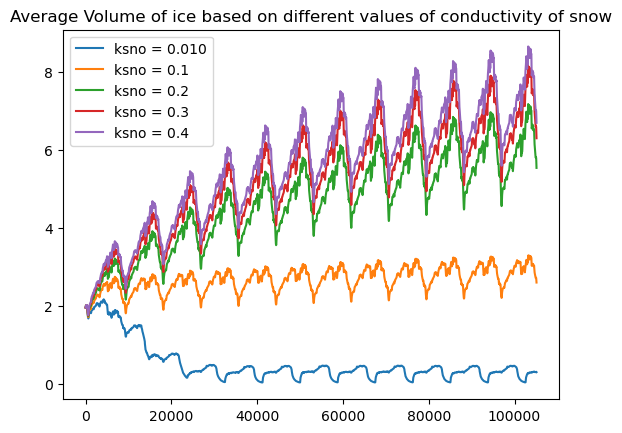

In [5]:
plt.plot(v001, label ="ksno = 0.010")
plt.plot(v01, label ="ksno = 0.1")
plt.plot(v02, label ="ksno = 0.2")
plt.plot(v03, label ="ksno = 0.3")
plt.plot(v04, label ="ksno = 0.4")
plt.title("Average Volume of ice based on different values of conductivity of snow")
plt.legend()
plt.show()

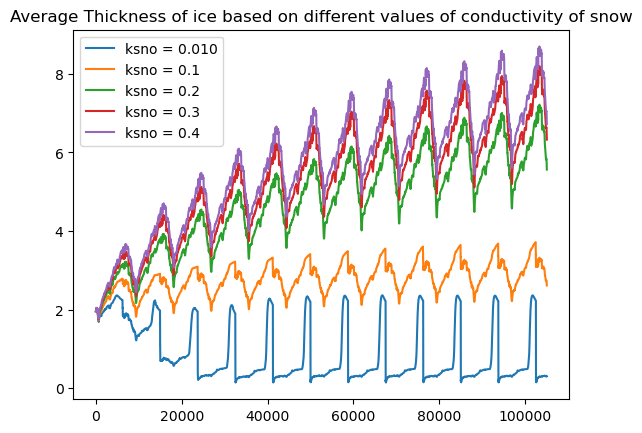

In [6]:
plt.plot(v001/a001, label ="ksno = 0.010")
plt.plot(v01/a01, label ="ksno = 0.1")
plt.plot(v02/a02, label ="ksno = 0.2")
plt.plot(v03/a03, label ="ksno = 0.3")
plt.plot(v04/a04, label ="ksno = 0.4")
plt.title("Average Thickness of ice based on different values of conductivity of snow")
plt.legend()
plt.show()

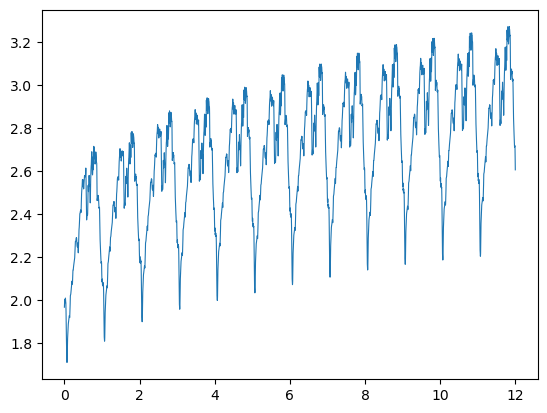

In [7]:
daily = v01.reshape(-1, 24).mean(axis=1)
plt.plot(np.arange(daily.size) / 365, daily, lw=0.8)

norm() { tr 'A-Z' 'a-z' < "$1" | sed -E 's/[[:space:]]+//g; s/d0\b//g'; }
diff <(norm /projects/dagr5998/icepack-dirs/runs/centralarctic_forced_test/icepack_in) <(norm /projects/kabo1917/icepack-dirs/runs/Spinup_CentralArctic_test/mem0001/icepack_in)